### Kalman Filter

In [ ]:
"""
Kalman Filter Velocity Estimation
@author:    Eder H. N. Silva
Date:       March 10, 2024
"""
%reset

In [1]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The Kalman filter (KF) estimates the state $x \in \mathbb{R}^{n}$ f a discrete-time system governed by the linear stochastic difference equation. The state $x_{k}$ at sampling instant $k$ evolves from the prior state at time $k-1$ as follows 

\begin{equation}
x_{k} = \Phi_{k} x_{k-1} + \Gamma_{k}u_{k} + w_{k}
\end{equation}

Where $x_{k}$ epresents the state at time $k$, $x_{k-1}$ represents the state at the previous time step,  $\Phi_{k} \in \mathbb{R}^{n \times n}$ is the state transition matrix, $\Gamma_{k} \in \mathbb{R}^{n \times r}$ is the input transition matrix, $u$ represents known control inputs, and $w$ is the process noise vector with zero mean and covariance $Q$. The observation model is:

\begin{equation}
z_{k} = H x_{k} + v_{k}
\end{equation}

where $z_{k}$ is the measurement vector at time  $k$, $H \in \mathbb{R}^{n \times n}$ maps the state vector into the measurement domain, and $v_{k}$ is the measurement noise vector with zero mean and covariance $R$.

In most linear dynamic systems applications, including ours, the $w_{k}$ and $v_{k}$ noises are uncorrelated white Gaussian noises due to modeling errors and measurement inaccuracies.

$\textbf{Prediction step}$

The initial estimate $\hat{x}_{k|k-1}$,(a priori) is based on the previous estimate $\hat{x}_{k-1|k-1}$, weighted by state transition matrix $\Phi$, and control input matrix $\Gamma$:

\begin{equation}
\hat{x}_{k|k-1} = \Phi \hat{x}_{k-1|k-1} + \Gamma u_{k}
\end{equation}

In [ ]:
x_pri = Phi.dot(x_pos) + Gamma.dot(u)

The a priori error covariance matrix $P_{k|k-1}$ is updated from its previous value $P_{k-1|k-1}$, incorporating $\Phi$ and process noise $Q_{k}$:

\begin{equation}
P_{k|k-1} = \Phi P_{k-1|k-1} \Phi^{T} + Q_{k}
\end{equation}

In [ ]:
P_pri = (Phi.dot(P_pos)).dot(Phi.transpose()) + Q

$\textbf{Update step}$

The Kalman gain $\bar{K}_{k}$ is computed based on the a priori error covariance $P_{k|k-1}$, the observation matrix $H$ , and measurement noise $R_{k}$:


\begin{equation*}
\bar{K}_{k} = P_{k|k-1} H^{T} [H P_{k|k-1} H^{T} + R_{k}]^{-1}
\end{equation*}

In [ ]:
K = (P_pri.dot(H.transpose())) * (np.linalg.inv(((H).dot(P_pri)).dot(H.transpose()) + R))

The posteriori state estimate $\hat{x}_{k|k}$ is calculated using the a priori estimate $\hat{x}_{k|k-1}$,  Kalman gain $\bar{K}_{k}$, and measurement $z_{k}$:

\begin{equation*}
\hat{x}_{k|k} = \hat{x}_{k|k-1} + \bar{K}_{k} [z_{k}- H \hat{x}_{k|k-1}]
\end{equation*}

In [ ]:
x_pos = x_pri + K.dot((z - H.dot(x_pri)))

The posteriori error covariance $P_{k|k}$ is updated from $P_{k|k-1}$ and $H$: 

\begin{equation*}
P_{k|k} = [I-K_{k}H]P_{k|k-1}
\end{equation*}

In [ ]:
P_pos = P_pri - K.dot(H.dot(P_pri))

The filter aims to ensure that $P \rightarrow 0$ as $k \rightarrow \infty$, though $P$ may converge to a nonzero steady-state value in general.

The process and measurement noise covariance matrices $Q_{k}$ and $R_{k}$ are characterized as:

\begin{equation*}
\begin{aligned}
E \langle w_{k} w_{k}^{T}\rangle = Q_{k}\\
\end{aligned}
\end{equation*}

\begin{equation*}
\begin{aligned}
E \langle v_{k} v_{k}^{T}\rangle = R_{k}
\end{aligned}
\end{equation*}

In [3]:

t = .05
Phi = np.array([[1,t],[0,1]])
Gamma = np.array([[0,t]])
H = np.array([[1,0],[0,0]])
Q = np.array([[1e-3,0],[0,10]])
R = np.array([[1,.0],[0,.1]])

# INITIALIZATION OF STATE AND COVARIANCE MATRICES
x_pos = np.array([[0],[0]])
P_pos = np.array([[0,0],[0,0]])
update = [x_pos,P_pos]

x_previous = [0]*3
acel_previous = [0]*20

def kalman_filter(position,x_pos,P_pos):
    """
    Kalman Filter Velocity Estimation
    @author:    Eder H. N. Silva
    Date:       March 10, 2024
    """

    ## MOVING AVERAGE ##
    x_previous.append(position)
    x_previous.pop(0)
    acel = ((x_previous[2]-x_previous[1])-(x_previous[1]-x_previous[0]))*(1/t**2)
    acel_previous.append(acel)
    acel_previous.pop(0)
    avr_acel = (sum(acel_previous)/len(acel_previous))
    print()


    ##  PREDICTION STEP  ##
    #A PRIORI STATE ESTIMATE
    x_pri = Phi.dot(x_pos) + Gamma.dot(avr_acel)


    #A PRIORI COVARIANCE MATRIX ESTIMATE
    P_pri = (Phi.dot(P_pos)).dot(Phi.transpose()) + Q
    ##  UPDATE STEP  ##
    #KALMAN GAIN
    K = (P_pri.dot(H.transpose()))*(np.linalg.inv(((H).dot(P_pri)).dot(H.transpose())+R))


    #A POSTERIORI STATE ESTIMATE
    x_pos = x_pri + K.dot(([[position],[0]] - H.dot(x_pri)))


    #A POSTERIORI COVARIANCE MATRIX ESTIMATE
    P_pos = P_pri - K.dot(H.dot(P_pri))
    return x_pos, P_pos

=========================================================================================================================================

## TESTE NUMERICO

In [6]:
x1 = pd.read_csv('encoder.csv',header=None)
x =[]
#Conversão para radianos
x1 = (x1*360)/1024

x2_real =[0]
for i in range(len(x1)-1):
    x2_real.append((((x1[0][i+1])-x1[0][i]))*20)
    
for i in range(len(x1)):
    update = kalman_filter(x1[0][i],update[0],update[1])
    #time.sleep(t)
    x.append(update[0])
    
#X1 = pd.DataFrame(X1)
X1 =[]
X2 =[]
for i in range(len(x)):
    X1.append(x[i][0][0])
    X2.append(x[i][1][1])

    

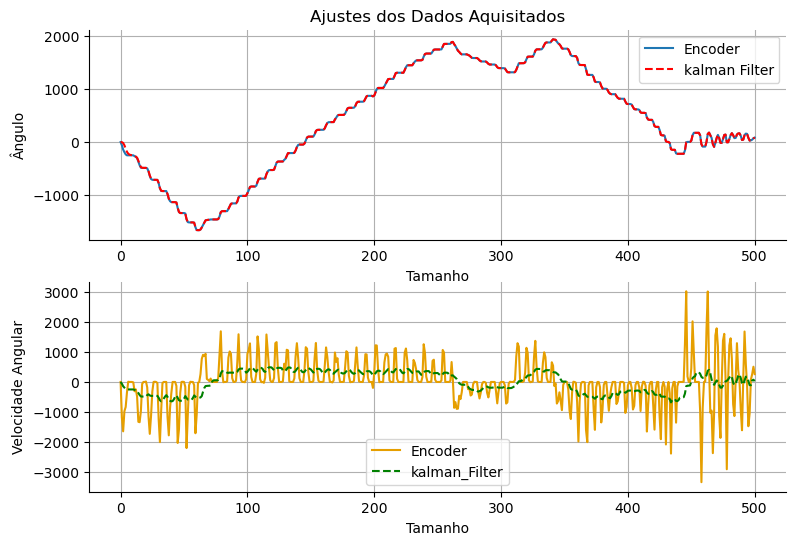

In [8]:
n=np.arange(0,len(X1),1)
plt.figure(figsize=(9,6))
plt.subplot(211)
plt.plot(n,x1, label='Encoder')
plt.plot(n,X1,color='r',linestyle='--',label='kalman Filter')
plt.title("Ajustes dos Dados Aquisitados")
plt.ylabel("Ângulo")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.subplot(212)
plt.plot(n,x2_real,color='#E69F00', label='Encoder')
plt.plot(n,X2,color='green',linestyle='--',label='kalman_Filter')
plt.ylabel("Velocidade Angular")
plt.xlabel("Tamanho")
plt.grid(True)
plt.legend()
sns.despine()
plt.show()

=========================================================================================================================================

## DISSERTAÇÃO

In [ ]:
## FILTER VARIABLES
t = .05
Phi = np.array([[1, t], [0, 1]])
Gamma = np.array([[0], [t]])
H = np.array([[1, 0], [0, 0]])
Q = np.array([[10, 0], [0, 10]])
R = np.array([[.1, 0], [0, 1]])
update = [np.array([[0], [0]]), np.array([[0], [0]]), np.array([[0, 0], [0, 0]]), np.array([[0, 0], [0, 0]])]
x_pri1 = [0] * 3
x_pri3 = [0] * 3
acel_pri1 = [0] * 20
acel_pri3 = [0] * 20


In [ ]:
def KalmanFilter(x1, x3, x1_pos, x3_pos, P1_pos, P3_pos):
    """
    Kalman Filter Velocity Estimation
    @author1:    Eder H. N. Silva
    @author2:    Gilmar
    Date:       March 10, 2024
    """
    """
    MOVING AVERAGE
    """
    x_pri1.pop(0)
    x_pri3.pop(0)
    acel_pri1.pop(0)
    acel_pri3.pop(0)
    x_pri1.append(x1)
    x_pri3.append(x3)
    acel_pri1.append(((x_pri1[2] - x_pri1[1]) - (x_pri1[1] - x_pri1[0])) * (1 / t * 2))
    acel_pri3.append(((x_pri3[2] - x_pri3[1]) - (x_pri3[1] - x_pri3[0])) * (1 / t * 2))
    acel_avr1 = (sum(acel_pri1) / 20)
    acel_avr3 = (sum(acel_pri3) / 20)
    """
    PREDICTION STEP
    """
    ## A PRIORI STATE ESTIMATE
    x1_pri = Phi.dot(x1_pos) + Gamma.dot(acel_avr1)
    x3_pri = Phi.dot(x3_pos) + Gamma.dot(acel_avr3)
    ## A PRIORI COVARIANCE MATRIX ESTIMATE
    P1_pri = (Phi.dot(P1_pos)).dot(Phi.transpose()) + Q
    P3_pri = (Phi.dot(P3_pos)).dot(Phi.transpose()) + Q
    """
    UPDATE STEP
    """
    ## KALMAN GAIN
    K1 = (P1_pri.dot(H.transpose())) * (np.linalg.inv(((H).dot(P1_pri)).dot(H.transpose()) + R))
    K3 = (P3_pri.dot(H.transpose())) * (np.linalg.inv(((H).dot(P3_pri)).dot(H.transpose()) + R))
    # A POSTERIORI STATE ESTIMATE
    x1_pos = x1_pri + K1.dot(([[x1], [0]] - H.dot(x1_pri)))
    x3_pos = x3_pri + K3.dot(([[x3], [0]] - H.dot(x3_pri)))
    # A POSTERIORI COVARIANCE MATRIX ESTIMATE
    P1_pos = P1_pri - K1.dot(H.dot(P3_pri))
    P3_pos = P3_pri - K3.dot(H.dot(P3_pri))
    return x1_pos, x3_pos, P1_pos, P3_pos

In [ ]:
update = KalmanFilter(ANGULO_1, ANGULO_2, update[0], update[1], update[2], update[3])